# 1. Regresión bayesiana estacional sin memoria

## Pregunta

¿Qué se obtiene si representamos solo el patrón solar esperado y la incertidumbre de sus parámetros?

Este primer modelo no usa rezagos ni términos autorregresivos. Nos sirve para introducir la actualización bayesiana y la predictiva posterior antes de hablar de memoria temporal.

In [1]:

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 17,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
    "figure.titlesize": 18,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
})


rng = np.random.default_rng(20260917) # semilla

df = pd.read_csv('data/solar_8760h.csv')
df["time"] = pd.date_range("2019-01-01", periods=len(df), freq="h")
df = df.set_index("time")
y = df["pv_kw_per_kwp"].to_numpy(float)
H = 168
cutoff = len(y) - H
train_index, test_index = df.index[:cutoff], df.index[cutoff:]
train, observed = y[:cutoff], y[cutoff:]

tmp = df.iloc[:cutoff].assign(month=lambda x: x.index.month, hour_of_day=lambda x: x.index.hour)
daylight = tmp.groupby(["month", "hour_of_day"])["ghi_kw_m2"].median()

def enforce_physics(values, index):
    # Limita la generación solar al intervalo [0, 1] y la fija en cero
    result = np.clip(np.asarray(values, float), 0.0, 1.0)
    for j, timestamp in enumerate(index):
        if daylight.loc[(timestamp.month, timestamp.hour)] <= 0.01:
            result[j] = 0.0
    return result

def mae(actual, forecast):
    return np.mean(np.abs(actual - forecast))

def rmse(actual, forecast):
    return np.sqrt(np.mean((actual - forecast) ** 2))

naive = y[cutoff - H:cutoff] # Semana anterior - predice cada hora de prueba con la misma hora de la semana previa.
                             # Es el baseline para juzgar si el modelo bayesiano aporta valor.
print(f"Entrenamiento: {train_index[0]} a {train_index[-1]}")
print(f"Prueba: {test_index[0]} a {test_index[-1]}")
#naive

# Configuración común de fuentes para gráficas


Entrenamiento: 2019-01-01 00:00:00 a 2019-12-24 23:00:00
Prueba: 2019-12-25 00:00:00 a 2019-12-31 23:00:00


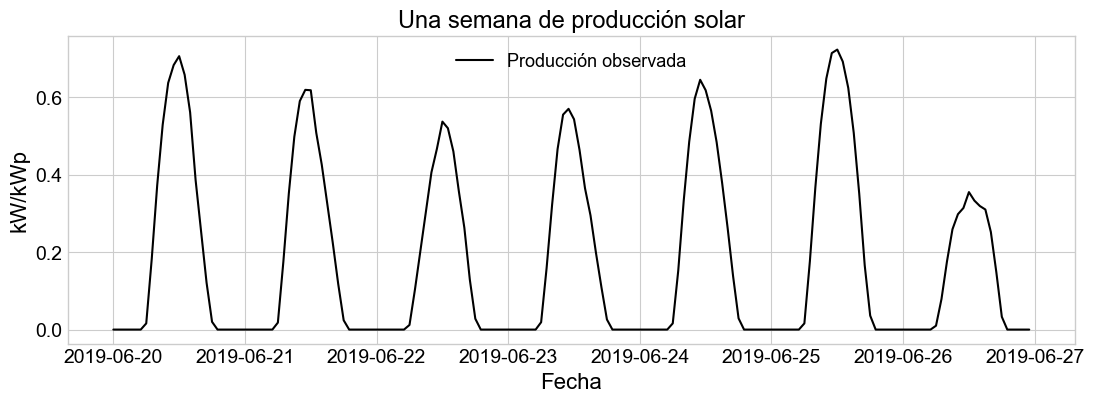

In [2]:
def design(index): # matriz Xt
    hour = index.hour.to_numpy()
    day = index.dayofyear.to_numpy()
    return np.column_stack([
        np.ones(len(index)),
        np.sin(2 * np.pi * hour / 24), np.cos(2 * np.pi * hour / 24),
        np.sin(4 * np.pi * hour / 24), np.cos(4 * np.pi * hour / 24),
        np.sin(2 * np.pi * day / 365), np.cos(2 * np.pi * day / 365)])

names = ["intercepto", "sin_h1", "cos_h1", "sin_h2", "cos_h2", "sin_anual", "cos_anual"]
X_train, X_test = design(train_index), design(test_index)
fig, ax = plt.subplots(figsize=(13, 4))
sample = slice(24 * 170, 24 * 177)
ax.plot(df.index[sample], y[sample], color="black", label="Producción observada")
ax.set(title="Una semana de producción solar", ylabel="kW/kWp", xlabel="Fecha")
ax.legend()
plt.show()

## Posterior conjugada

Con el prior conjugado

$$\beta\mid\sigma^2\sim N(m_0,\sigma^2V_0),\qquad \sigma^2\sim\operatorname{InvGamma}(a_0,b_0),$$

la posterior se calcula de forma analítica. Esto permite concentrarnos en la idea de muestrear parámetros y propagar la incertidumbre hacia trayectorias futuras.

In [3]:
from scipy.stats import invgamma

p = X_train.shape[1]
m0 = np.zeros(p)
V0 = 10.0 * np.eye(p)
V0_inv = np.linalg.inv(V0)
a0, b0 = 2.0, 0.05

Vn = np.linalg.inv(V0_inv + X_train.T @ X_train)
mn = Vn @ (V0_inv @ m0 + X_train.T @ train)
an = a0 + len(train) / 2
bn = b0 + 0.5 * (train @ train + m0 @ V0_inv @ m0 - mn @ np.linalg.inv(Vn) @ mn)

N_DRAWS = 2000
sigma2_draws = invgamma.rvs(an, scale=bn, size=N_DRAWS, random_state=rng)
beta_draws = np.vstack([rng.multivariate_normal(mn, sigma2 * Vn) for sigma2 in sigma2_draws])

posterior = pd.DataFrame({"media": beta_draws.mean(axis=0), "q05": np.quantile(beta_draws, 0.05, axis=0),
                          "q95": np.quantile(beta_draws, 0.95, axis=0),}, index=names)
display(posterior.round(4))

,media,q05,q95
intercepto,0.2103,0.2090,0.2115
sin_h1,0.0032,0.0014,0.0050
cos_h1,-0.3387,-0.3405,-0.3370
sin_h2,-0.0065,-0.0083,-0.0047
cos_h2,0.1610,0.1591,0.1627
sin_anual,0.0267,0.0249,0.0285
cos_anual,0.0064,0.0046,0.0081


## Prior frente a posterior de los parámetros

Para comparar el prior con la posterior, generamos muestras del prior conjunto
de \(\boldsymbol{\beta}\) y \(\sigma\). Los intervalos muestran el rango central
del \(90\%\) antes y después de observar la serie.

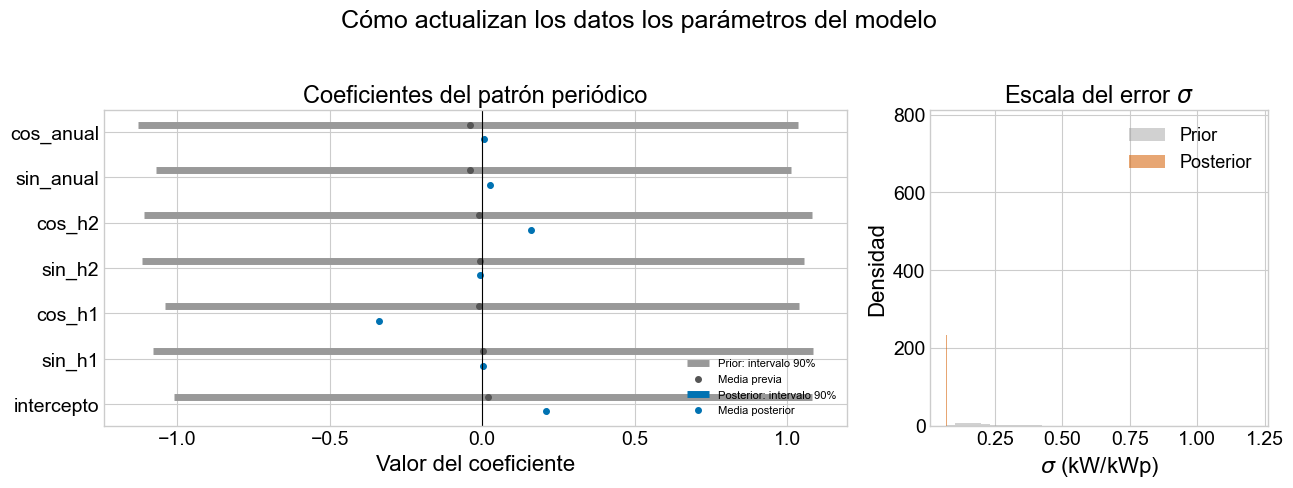

In [4]:
from scipy.stats import invgamma

# Muestras del prior conjunto: primero sigma^2 y luego beta | sigma^2.
prior_sigma2 = invgamma.rvs(a0, scale=b0, size=N_DRAWS, random_state=rng)
prior_beta = np.vstack([
    rng.multivariate_normal(m0, sigma2 * V0)
    for sigma2 in prior_sigma2
])

prior_q05, prior_q95 = np.quantile(prior_beta, [0.05, 0.95], axis=0)
post_q05, post_q95 = np.quantile(beta_draws, [0.05, 0.95], axis=0)
prior_mean = prior_beta.mean(axis=0)
post_mean = beta_draws.mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw={"width_ratios": [2.2, 1]})
fig.patch.set_facecolor("white")

ypos = np.arange(len(names))
axes[0].hlines(ypos + 0.16, prior_q05, prior_q95, color="#999999", lw=5, label="Prior: intervalo 90%")
axes[0].plot(prior_mean, ypos + 0.16, "o", color="#555555", ms=4, label="Media previa")
axes[0].hlines(ypos - 0.16, post_q05, post_q95, color="#0072B2", lw=5, label="Posterior: intervalo 90%")
axes[0].plot(post_mean, ypos - 0.16, "o", color="#0072B2", ms=4, label="Media posterior")
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set(yticks=ypos, yticklabels=names, xlabel="Valor del coeficiente", title="Coeficientes del patrón periódico")
axes[0].legend(loc="lower right", fontsize=8)

axes[1].hist(np.sqrt(prior_sigma2), bins=35, density=True, alpha=.45, color="#999999", label="Prior")
axes[1].hist(np.sqrt(sigma2_draws), bins=35, density=True, alpha=.55, color="#D55E00", label="Posterior")
axes[1].set(title=r"Escala del error $\sigma$", xlabel=r"$\sigma$ (kW/kWp)", ylabel="Densidad")
axes[1].legend()

fig.suptitle("Cómo actualizan los datos los parámetros del modelo", y=1.02)
fig.tight_layout()
plt.show()


## Predictiva posterior

Cada trayectoria toma un par $(\beta,\sigma)$ de la posterior y simula errores independientes. Al comparar las trayectorias con los datos, preguntamos: ¿qué estructura falta?

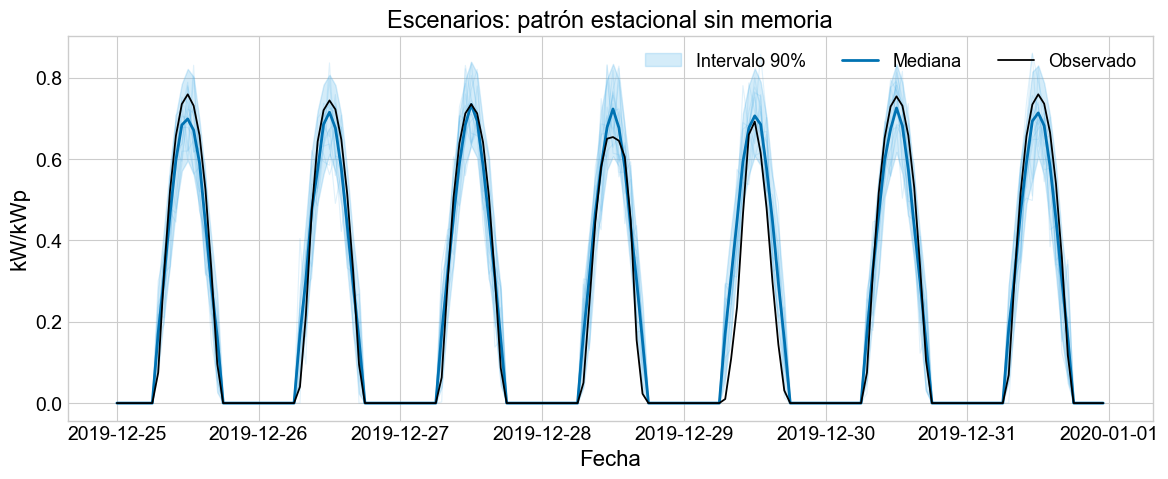

,MAE,RMSE,Cobertura_90
Semana anterior,0.0349,0.0816,NaN
Estacional bayesiano,0.0296,0.0534,0.9464


In [5]:
N_SCENARIOS = 100
selected = rng.choice(N_DRAWS, N_SCENARIOS, replace=False)
scenarios = np.vstack([ enforce_physics(X_test @ beta_draws[j] + rng.normal(0, np.sqrt(sigma2_draws[j]), H), test_index)
    for j in selected ])

median = np.median(scenarios, axis=0)
q05, q95 = np.quantile(scenarios, [0.05, 0.95], axis=0)

fig, ax = plt.subplots(figsize=(14, 5))
for path in scenarios[:15]:
    ax.plot(test_index, path, color="#56B4E9", alpha=0.18, lw=0.8)
ax.fill_between(test_index, q05, q95, color="#56B4E9", alpha=0.25, label="Intervalo 90%")
ax.plot(test_index, median, color="#0072B2", lw=2, label="Mediana")
ax.plot(test_index, observed, color="black", lw=1.3, label="Observado")
ax.set(title="Escenarios: patrón estacional sin memoria", ylabel="kW/kWp", xlabel="Fecha")
ax.legend(ncol=3)
fig.savefig('Figures/forecast_bayes_estacional.pdf', dpi=220, bbox_inches="tight")
plt.show()

results = pd.DataFrame({ "MAE": [mae(observed, naive), mae(observed, median)],
    "RMSE": [rmse(observed, naive), rmse(observed, median)],
    "Cobertura_90": [np.nan, np.mean((observed >= q05) & (observed <= q95))],
}, index=["Semana anterior", "Estacional bayesiano"])
display(results.round(4))

## ¿Queda memoria después de quitar el patrón?

Para separar el ciclo solar de la memoria de corto plazo, calculamos los residuos respecto al patrón posterior medio:

$$r_t=y_t-x_t^\top\hat\beta.$$

La gráfica compara residuos consecutivos. Si no quedara estructura temporal, la nube de puntos no mostraría una dirección clara.

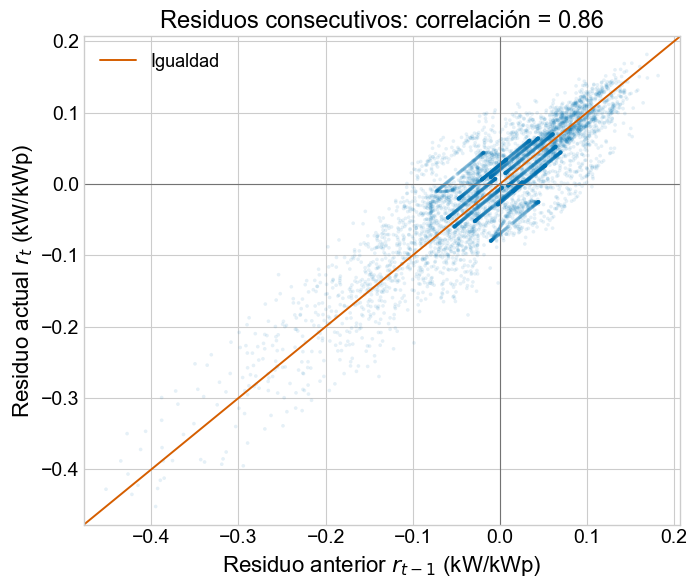

Correlación residual de una hora: 0.861


In [6]:
residuals = train - X_train @ mn
residual_pairs = pd.DataFrame({
    "r_t": residuals[1:],
    "r_t_minus_1": residuals[:-1],
}, index=train_index[1:])
residual_corr = residual_pairs["r_t"].corr(residual_pairs["r_t_minus_1"])

fig, ax = plt.subplots(figsize=(7.2, 6.1))
ax.scatter(
    residual_pairs["r_t_minus_1"], residual_pairs["r_t"],
    s=7, alpha=0.10, color="#0072B2", edgecolors="none",
)
limits = np.array([
    residual_pairs.to_numpy().min(), residual_pairs.to_numpy().max()
])
pad = 0.04 * np.ptp(limits)
limits += [-pad, pad]
ax.plot(limits, limits, color="#D55E00", lw=1.4, label="Igualdad")
ax.axhline(0, color="0.45", lw=0.8)
ax.axvline(0, color="0.45", lw=0.8)
ax.set(
    title=f"Residuos consecutivos: correlación = {residual_corr:.2f}",
    xlabel=r"Residuo anterior $r_{t-1}$ (kW/kWp)",
    ylabel=r"Residuo actual $r_t$ (kW/kWp)",
    xlim=limits, ylim=limits,
)
ax.legend(loc="upper left")
fig.tight_layout()

fig.savefig("Figures/solar_residual_lag1.pdf", dpi=220, bbox_inches="tight")
plt.show()
print(f"Correlación residual de una hora: {residual_corr:.3f}")

## Qué falta

El modelo aprende el ciclo esperado, pero cada innovación futura es independiente. Por ello no representa bien secuencias completas de nubosidad o de alta producción. El siguiente notebook añade memoria a las desviaciones mediante un residual AR(1).